<a href="https://colab.research.google.com/github/mugu2005/Iris-Classification-ML-/blob/main/Iris_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

Upload Dataset


In [2]:
from google.colab import files

uploaded = files.upload()

Saving Iris.csv to Iris.csv


Load Dataset

In [3]:
df = pd.read_csv("Iris.csv")

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


Inspect Dataset

In [4]:
print("Shape:", df.shape)

df.info()

df.describe()

df.isnull().sum()

df.duplicated().sum()

Shape: (150, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


np.int64(0)

Data Preprocessing

Explanation:
In this step, we clean the dataset, check for missing values and duplicates, remove unnecessary columns, and prepare the data for machine learning.

In [5]:
# Remove the Id column as it is not useful for prediction
df = df.drop('Id', axis=1)

# Check for missing values
print(df.isnull().sum())

# Check for duplicate records
print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicates if any
df = df.drop_duplicates()

# Display the cleaned dataset
df.head()

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64
Duplicate Rows: 3


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


Label Encoding

Explanation:
Machine learning models cannot work directly with text labels such as Iris-setosa. We convert them into numeric values.

In [6]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['Species'] = encoder.fit_transform(df['Species'])

df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Feature Selection

Explanation:
Separate the input features (X) from the target variable (y).

In [7]:
X = df.drop('Species', axis=1)

y = df['Species']

print(X.head())
print(y.head())

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2
0    0
1    0
2    0
3    0
4    0
Name: Species, dtype: int64


Correlation Heatmap

Explanation:
This heatmap shows how strongly the numerical features are related to each other.

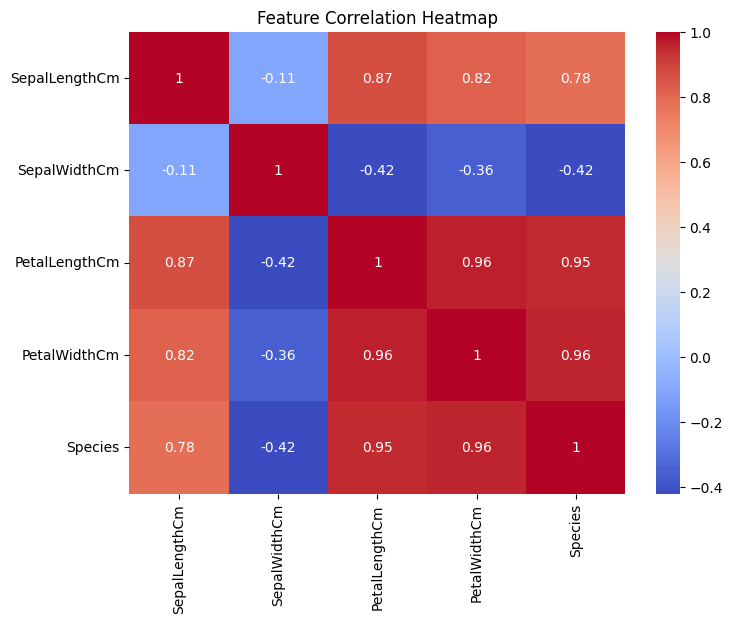

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")

plt.show()

Train-Test Split

Explanation:
Split the dataset into 80% training data and 20% testing data.

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (117, 4)
Testing Data: (30, 4)


Model 1 – Logistic Regression

Explanation:
Logistic Regression is a classification algorithm that predicts the class of an input based on its features. It is simple, fast, and performs well on linearly separable data.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Create the model
lr = LogisticRegression(max_iter=200)

# Train the model
lr.fit(X_train, y_train)

# Make predictions
lr_pred = lr.predict(X_test)

# Accuracy
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.9333333333333333


Model 2 – K-Nearest Neighbors (KNN)

Explanation:
KNN classifies a new data point based on the majority class of its nearest neighbors.

In [11]:
from sklearn.neighbors import KNeighborsClassifier

# Create the model
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(X_train, y_train)

# Make predictions
knn_pred = knn.predict(X_test)

# Accuracy
knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.9333333333333333


Model 3 – Random Forest

Explanation:
Random Forest combines multiple decision trees to improve prediction accuracy and reduce overfitting.


In [12]:
from sklearn.ensemble import RandomForestClassifier

# Create the model
rf = RandomForestClassifier(random_state=42)

# Train the model
rf.fit(X_train, y_train)

# Make predictions
rf_pred = rf.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9333333333333333


Model Evaluation

Explanation:
We evaluate each model using Accuracy, Precision, Recall, and F1-Score.

In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score

models = {
    "Logistic Regression": lr_pred,
    "KNN": knn_pred,
    "Random Forest": rf_pred
}

results = []

for model_name, prediction in models.items():
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, prediction),
        "Precision": precision_score(y_test, prediction, average='weighted'),
        "Recall": recall_score(y_test, prediction, average='weighted'),
        "F1 Score": f1_score(y_test, prediction, average='weighted')
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.933333,0.933333,0.933333,0.933333
1,KNN,0.933333,0.933333,0.933333,0.933333
2,Random Forest,0.933333,0.933333,0.933333,0.933333


Model Comparison

Explanation:
The table below compares the performance of all three machine learning models.

In [14]:
results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.933333,0.933333,0.933333,0.933333
1,KNN,0.933333,0.933333,0.933333,0.933333
2,Random Forest,0.933333,0.933333,0.933333,0.933333


Confusion Matrix

Explanation:
A confusion matrix shows how many predictions were correct and where the model made mistakes. It helps us evaluate the classification performance in detail.

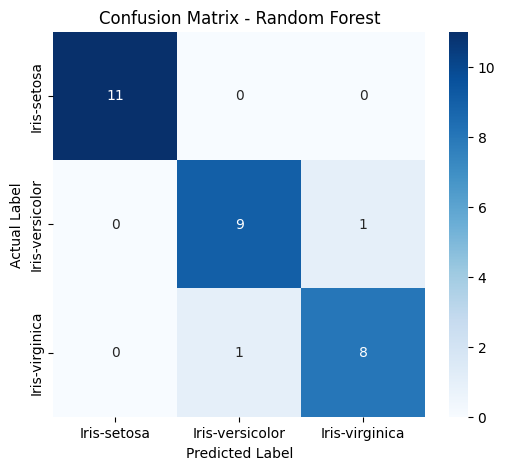

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Choose the best model
best_model = rf
best_predictions = rf_pred

# Create confusion matrix
cm = confusion_matrix(y_test, best_predictions)

# Plot confusion matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

Classification Report

Explanation:
The classification report provides Precision, Recall, F1-Score, and Support for each class, giving a detailed view of model performance

In [16]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    best_predictions,
    target_names=encoder.classes_
))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.89      0.89      0.89         9

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



Best Model Analysis
Explanation

Based on the evaluation metrics, Random Forest achieved the highest overall performance among the three models. It correctly classified most flower species with high Accuracy, Precision, Recall, and F1-Score. Random Forest combines multiple decision trees, making it more robust and less prone to overfitting than individual models.

Conclusion

This project successfully developed and evaluated three machine learning classification models using the Iris dataset. After preprocessing the data and splitting it into training and testing sets, Logistic Regression, K-Nearest Neighbors, and Random Forest models were trained and evaluated. Based on the comparison of Accuracy, Precision, Recall, and F1-Score, Random Forest demonstrated the best overall performance. This project highlights the importance of comparing multiple algorithms before selecting the most suitable model for a classification task.

In [17]:
results_df.to_csv("Model_Comparison_Table.csv", index=False)

print("Comparison table saved successfully!")

Comparison table saved successfully!
